In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sensible default appearance
sns.set_theme(style="whitegrid", context="talk")

In [2]:
# Load example datasets
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")
penguins = sns.load_dataset("penguins")

print("Datasets loaded:")
print("tips:", tips.shape)
print("flights:", flights.shape)
print("penguins:", penguins.shape)

Datasets loaded:
tips: (244, 7)
flights: (144, 3)
penguins: (344, 7)


In [4]:
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
flights.head(5)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [6]:
penguins.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# What is Wrong with these plots?!

## Passengers by Year

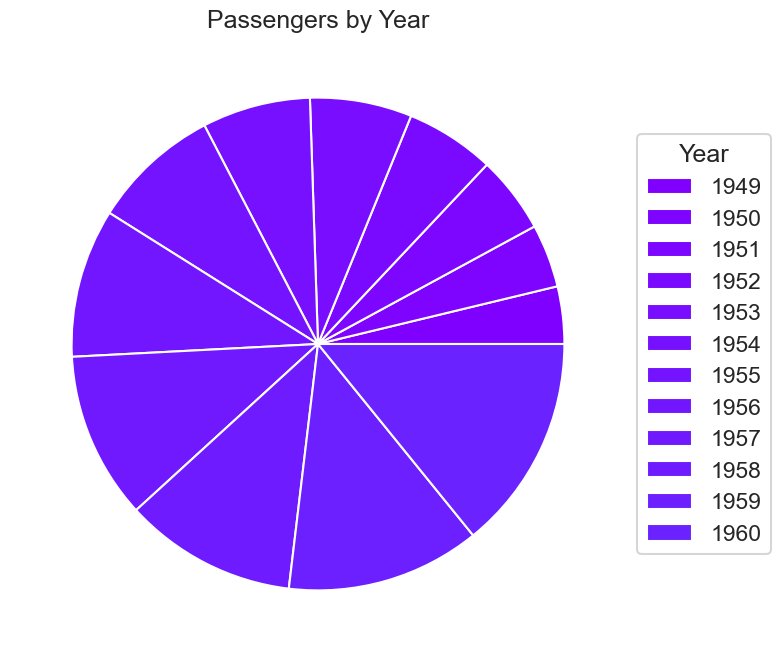

In [21]:
plt.figure(figsize=(8,8))

plt.pie(
    flights_by_year["passengers"],
    colors=plt.cm.rainbow(range(len(flights_by_year)))
) ##PIE CHART

plt.legend(
    flights_by_year["year"],
    title="Year",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
) ##ADDS LEGEND

plt.title("Passengers by Year")
plt.show()

### Fix Color Scheme

Color scheme is adequate. It is very hard to distinguish between different years. 

Also, color does not represent different categories — it only makes the chart harder to read.

Using a single sequential color palette reduces visual noise and keeps attention on the values themselves.

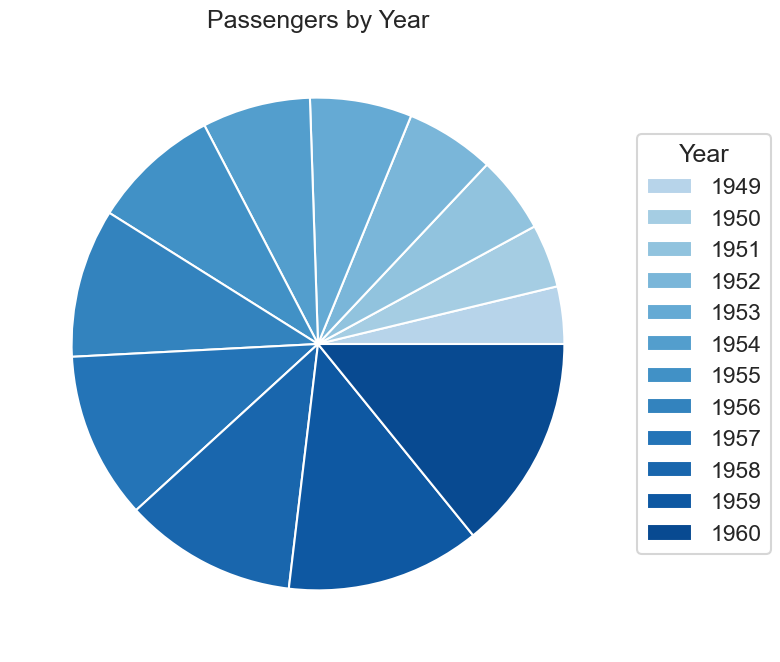

In [22]:
plt.figure(figsize=(8,8))

plt.pie(
    flights_by_year["passengers"],
    colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(flights_by_year))) ##ADDED FIX
)

plt.legend(
    flights_by_year["year"],
    title="Year",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Passengers by Year")
plt.show()

### Move Legend Closer to the Plot

Legends force the reader to move their eyes back and forth between the legend and the chart. This increases cognitive effort.

Placing labels directly on the slices removes this extra step and allows the reader to interpret the chart more quickly.

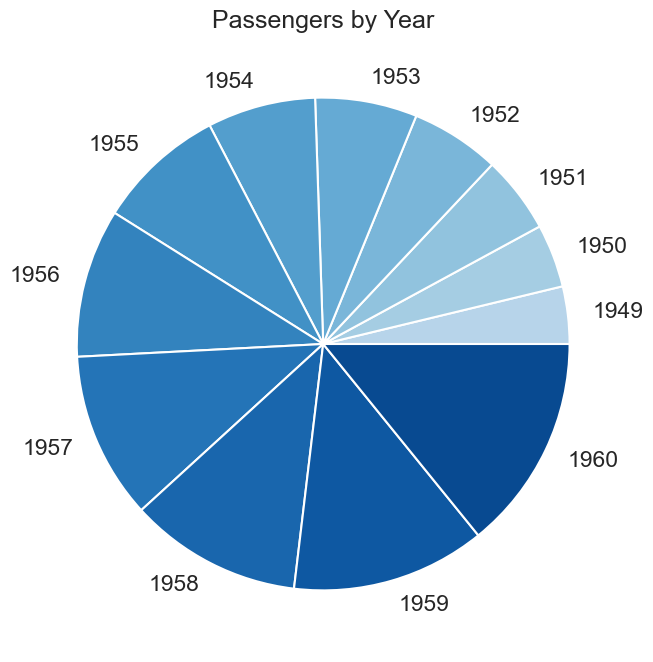

In [23]:
plt.figure(figsize=(8,8))

plt.pie(
    flights_by_year["passengers"],
    labels=flights_by_year["year"], ##ADDED FIX, NO MORE LEGEND
    colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(flights_by_year)))
)

plt.title("Passengers by Year")
plt.show()

### Add percentages to help comparison

Pie charts encode values using angles, which are difficult for humans to compare accurately.

Adding percentage labels helps the reader quantify the differences between slices and improves interpretability.

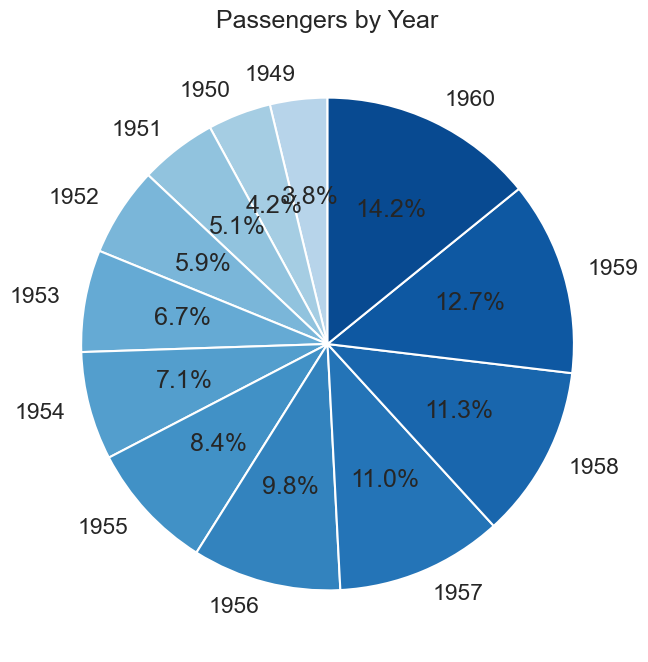

In [24]:
plt.figure(figsize=(8,8))

plt.pie(
    flights_by_year["passengers"],
    labels=flights_by_year["year"],
    autopct="%1.1f%%", ##ADDED FIX
    colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(flights_by_year))),
    startangle=90
)

plt.title("Passengers by Year")
plt.show()

### Pick the right plot type

Even after improving the pie chart, it remains difficult to see trends over time.

Time series data is best represented with a line chart because the horizontal axis naturally represents time.
    
This allows the reader to immediately see trends and changes across years.

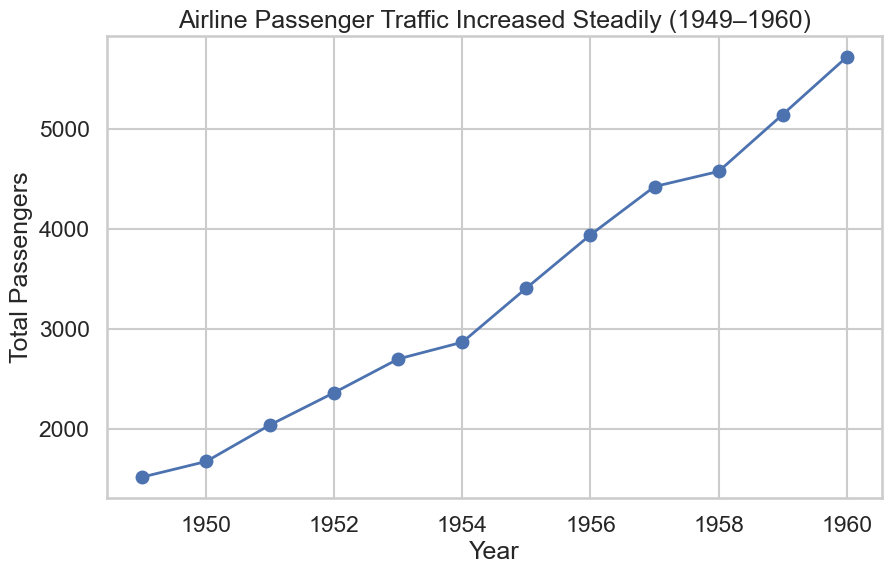

In [76]:
plt.figure(figsize=(10,6))
plt.plot(
flights_by_year["year"],
flights_by_year["passengers"],
marker="o",
linewidth=2)

plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.title("Airline Passenger Traffic Increased Steadily (1949–1960)")
plt.show()

## Tips by day

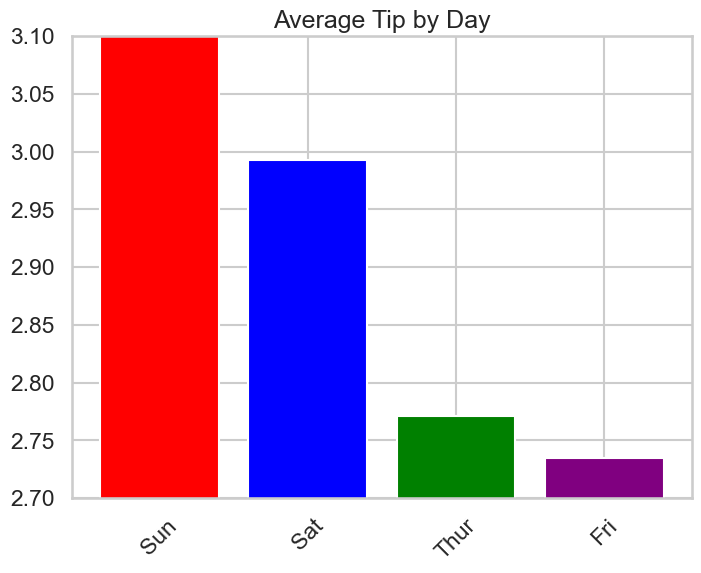

In [34]:
tips_by_day = tips.groupby("day", as_index=False)["tip"].mean()

tips_by_day = tips_by_day.sample(frac=1, random_state=1) #Disorder things

plt.figure(figsize=(8,6))

plt.bar(
    tips_by_day["day"],
    tips_by_day["tip"],
    color=["red","blue","green","purple"]
)

# Zoom
plt.ylim(2.7, 3.1)

plt.xticks(rotation=45)
plt.grid(True)

plt.title("Average Tip by Day")

plt.show()

### Zoom out

The previous chart used a truncated y-axis, which exaggerates small differences between values.

Bar charts represent values using the length of the bar relative to a baseline. If the axis does not start near zero, the visual differences can become misleading.

Restoring the full scale makes the visual differences match the numerical differences.

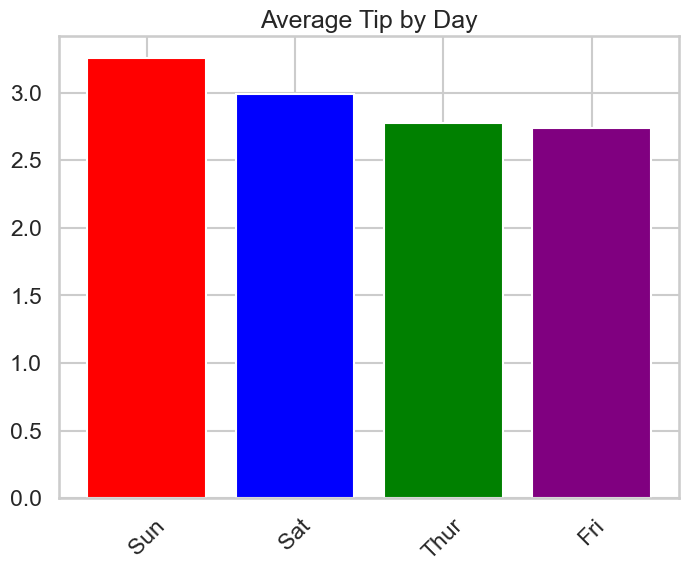

In [36]:
tips_by_day = tips.groupby("day", as_index=False)["tip"].mean()

tips_by_day = tips_by_day.sample(frac=1, random_state=1)

plt.figure(figsize=(8,6))

plt.bar(
    tips_by_day["day"],
    tips_by_day["tip"],
    color=["red","blue","green","purple"]
)

#REMOVE ZOOM

plt.xticks(rotation=45)
plt.grid(True)

plt.title("Average Tip by Day")

plt.show()

### Constant order from plot to plot

Random or inconsistent ordering makes comparisons more difficult because the reader must mentally reorganize the categories.

Keeping a consistent or logical ordering allows the viewer to compare values more quickly and easily.

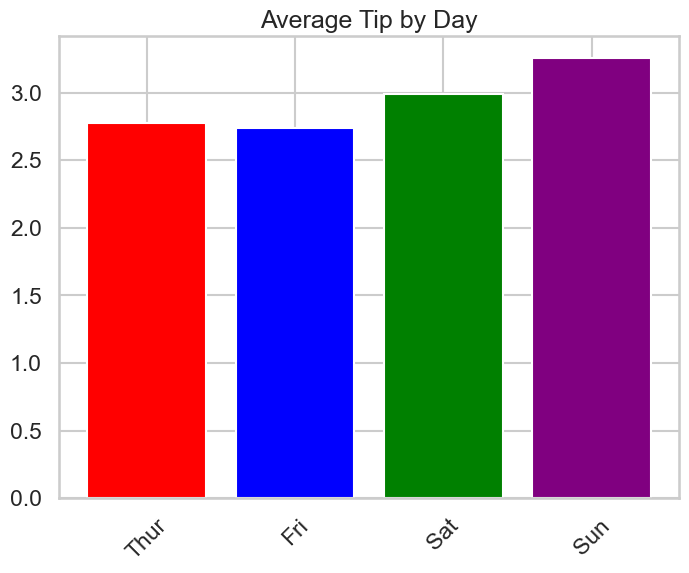

In [38]:
tips_by_day = tips.groupby("day", as_index=False)["tip"].mean() #FIX RANDOM ORDER

plt.figure(figsize=(8,6))
plt.bar(tips_by_day["day"], tips_by_day["tip"], color=["red", "blue", "green", "purple"])
plt.xticks(rotation=45)
plt.grid(True)
plt.title("Average Tip by Day")
plt.show()

### Remove Color

Different colors suggest that the categories represent different types of information.

In this chart, color does not encode any meaningful variable, so using multiple colors only adds visual noise.

A single neutral color keeps the focus on the bar lengths.

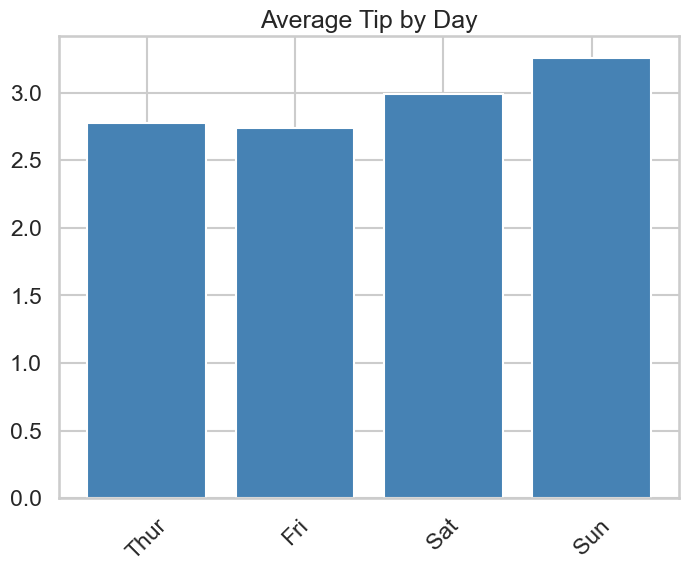

In [39]:
plt.figure(figsize=(8,6))
plt.bar(tips_by_day["day"], tips_by_day["tip"], color="steelblue") #FIX COLOR
plt.xticks(rotation=45)
plt.grid(True)
plt.title("Average Tip by Day")
plt.show()

### Add Axis Titles

Without clear axis labels, readers must guess what the values represent.

Adding axis titles clarifies what is being measured and makes the chart easier to interpret without additional context.

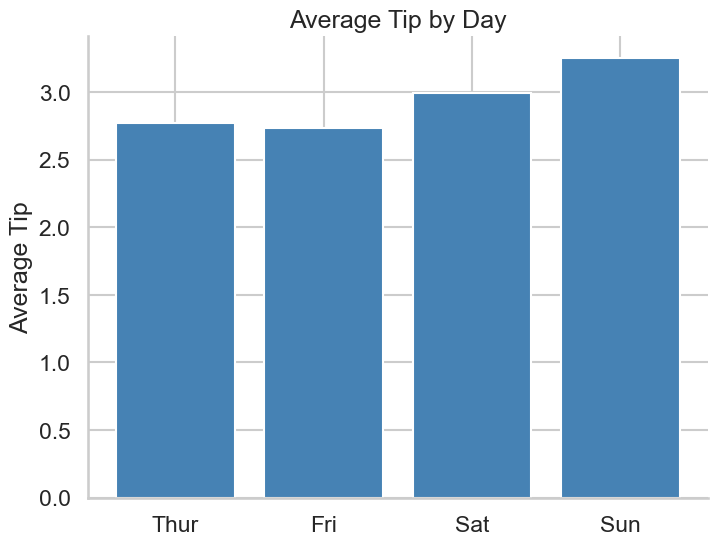

In [40]:
plt.figure(figsize=(8,6))
plt.bar(tips_by_day["day"], tips_by_day["tip"], color="steelblue")
plt.title("Average Tip by Day")
plt.ylabel("Average Tip") #FIX. ADDED LABELS 
sns.despine()
plt.show()

### Turn to Horizontal Bars (optional)

Horizontal bars make category labels easier to read, especially when labels are long or rotated.

They also allow value labels to be placed neatly beside the bars, improving readability.

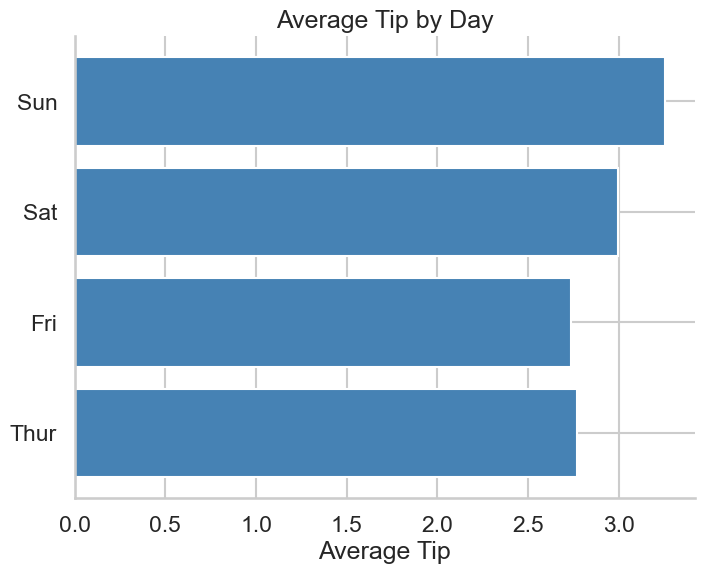

In [45]:
plt.figure(figsize=(8,6))
plt.barh(tips_by_day["day"], tips_by_day["tip"], color="steelblue") #FIX. MAKE HORIZONTAL BAR FOR READABILITY
plt.title("Average Tip by Day")
plt.xlabel("Average Tip")
sns.despine()
plt.show()

### Add direct labels

Direct labels allow readers to see exact values without estimating from the axis scale.

This reduces the effort required to interpret the chart and improves precision when comparing categories.

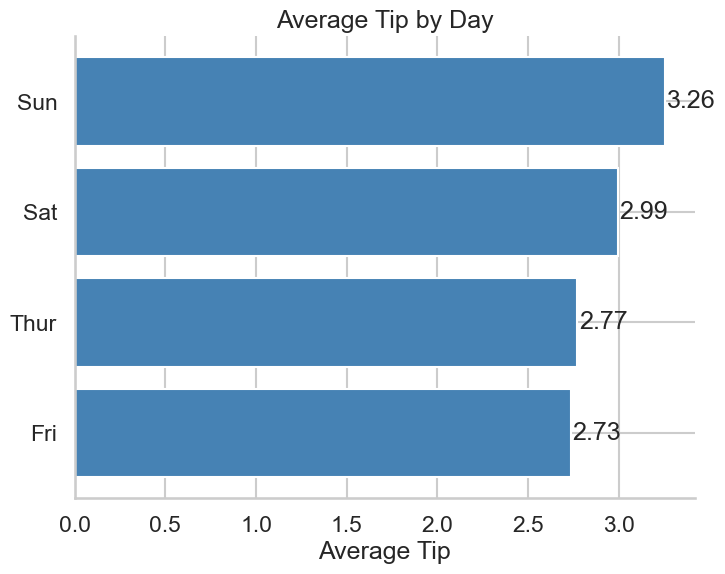

In [46]:
plt.figure(figsize=(8,6))
bars = plt.barh(tips_by_day_sorted["day"], tips_by_day_sorted["tip"], color="steelblue")
plt.title("Average Tip by Day")
plt.xlabel("Average Tip")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va="center") #FIX. ADD TEXT TO THE BARS

sns.despine()
plt.show()

## Bill vs Tips

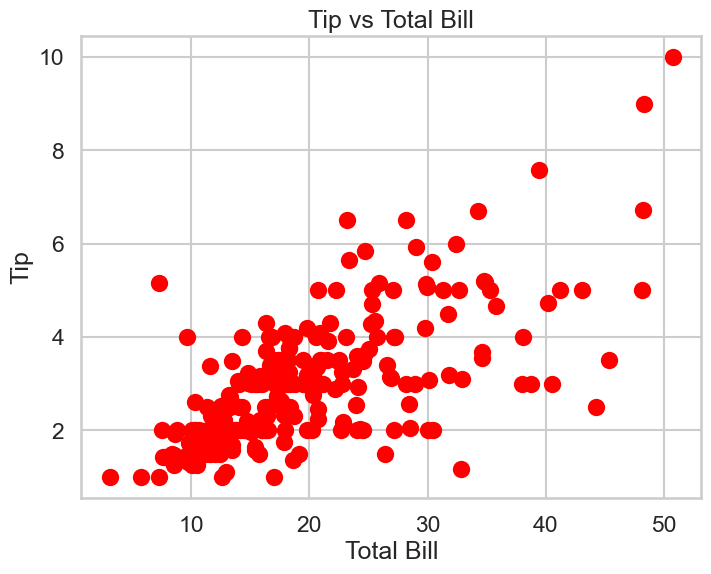

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(tips["total_bill"], tips["tip"], s=120, color="red")
plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

### Unnecesarily big dots

Large markers can overlap and hide patterns in the data.

Reducing point size makes individual observations easier to see and prevents the plot from becoming visually cluttered.

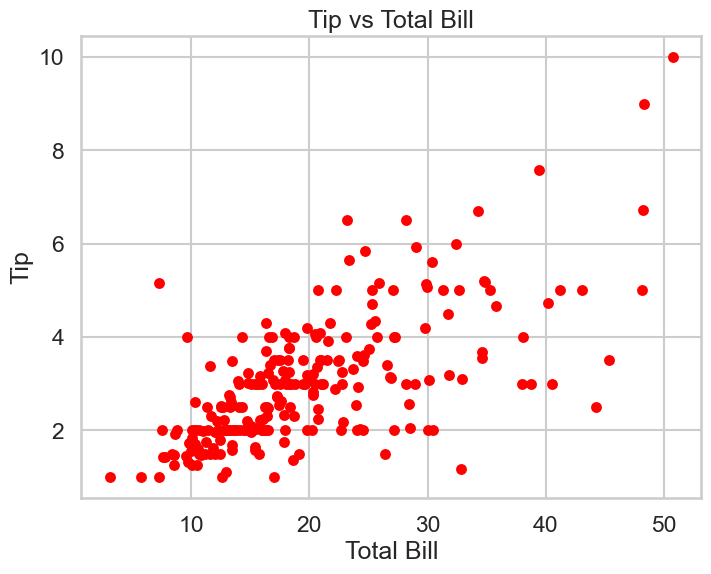

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(tips["total_bill"], tips["tip"], s=40, color="red") #FIX. CHANGED S FOR SIZE
plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

### Add transparency for dot density

When many points overlap, dense areas become difficult to interpret.

Transparency allows overlapping points to appear darker, revealing the density of observations in different regions of the plot.

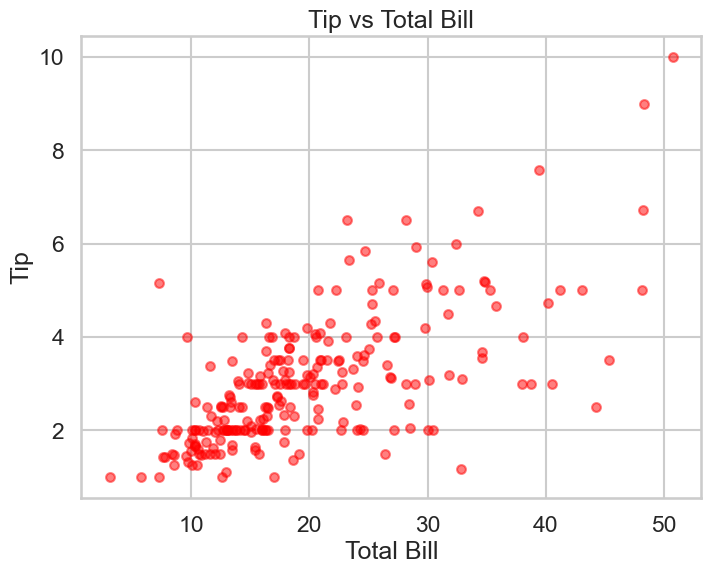

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(tips["total_bill"], tips["tip"], s=40, alpha=0.5, color="red") #FIX. ADDED ALPHA TO SET TRANSPARENCY
plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

### Add color to differentiate another category

Color can be used to encode an additional variable.

In this case, color differentiates lunch and dinner observations, allowing the reader to compare patterns between the two groups.

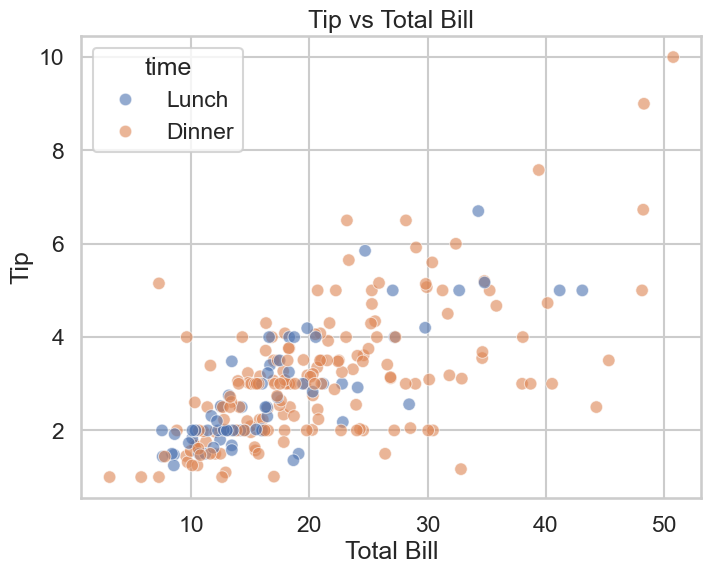

In [54]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", alpha=0.6) #FIX. ADDED HUE PARAMETER FOR COLOR
plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

### Add line of best fit and correlation

Scatter plots show individual observations but may not clearly reveal the overall relationship between variables.

Regression lines summarize the general trend in the data, while the correlation coefficient provides a quantitative measure of the strength of the relationship.

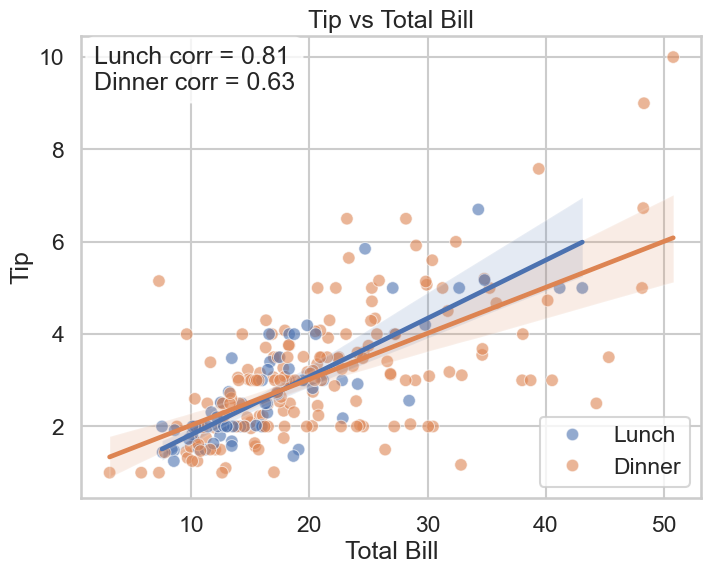

In [57]:
plt.figure(figsize=(8,6))

# Scatterplot
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="time",
    alpha=0.6
)

# FIX. Add regression lines for each group
sns.regplot(
    data=tips[tips["time"] == "Lunch"],
    x="total_bill",
    y="tip",
    scatter=False
)

sns.regplot(
    data=tips[tips["time"] == "Dinner"],
    x="total_bill",
    y="tip",
    scatter=False
)

# FIX. Compute correlations
corr_lunch = tips.loc[tips["time"] == "Lunch", ["total_bill", "tip"]].corr().iloc[0, 1]
corr_dinner = tips.loc[tips["time"] == "Dinner", ["total_bill", "tip"]].corr().iloc[0, 1]

# Add correlation text
plt.text(
    0.02, 0.98,
    f"Lunch corr = {corr_lunch:.2f}\nDinner corr = {corr_dinner:.2f}",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()

## Bill vs Flipper Length

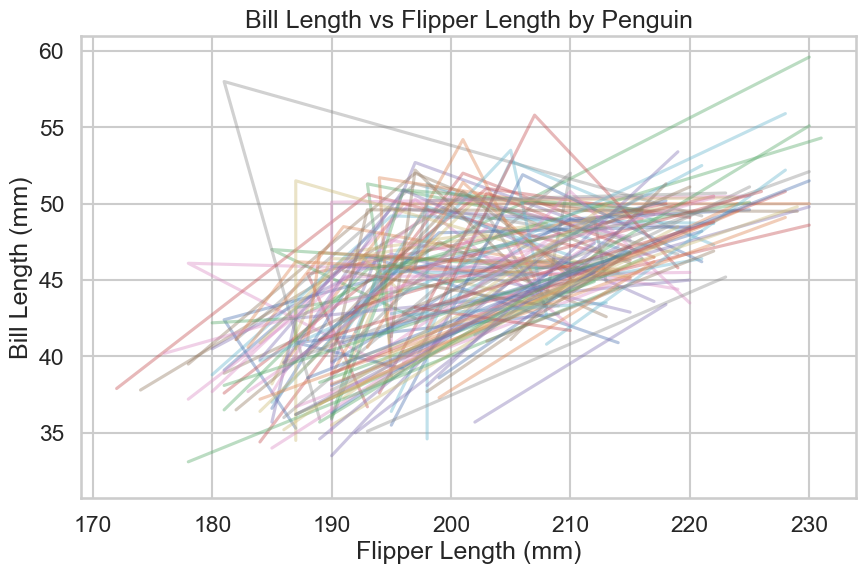

In [59]:
penguins_clean = penguins.dropna()

penguins_clean["penguin_id"] = penguins_clean.groupby("species").cumcount()

plt.figure(figsize=(10,6))

for _, group in penguins_clean.groupby("penguin_id"):
    plt.plot(
        group["flipper_length_mm"],
        group["bill_length_mm"],
        alpha=0.4
    )

plt.title("Bill Length vs Flipper Length by Penguin")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")
plt.show()

### One line per species, not per penguin

Drawing one line per individual penguin creates a tangled "spaghetti" plot that is difficult to interpret.

Grouping the data by species reduces the number of lines and highlights broader patterns in the data.

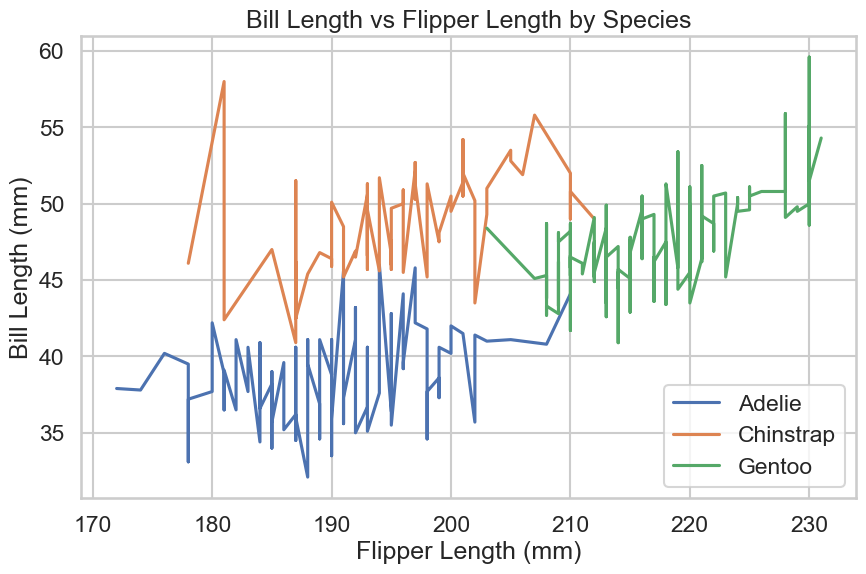

In [60]:
plt.figure(figsize=(10,6))

for species, group in penguins_clean.groupby("species"): #FIX. GROUP BY SPECIES
    group = group.sort_values("flipper_length_mm")
    plt.plot(
        group["flipper_length_mm"],
        group["bill_length_mm"],
        label=species
    )

plt.legend()
plt.title("Bill Length vs Flipper Length by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")
plt.show()

### Switch to the right plot type

Lines imply an ordered sequence, such as time. In this dataset, the observations are independent measurements, so connecting them with lines can be misleading.

Scatter plots are better suited for showing relationships between two continuous variables.

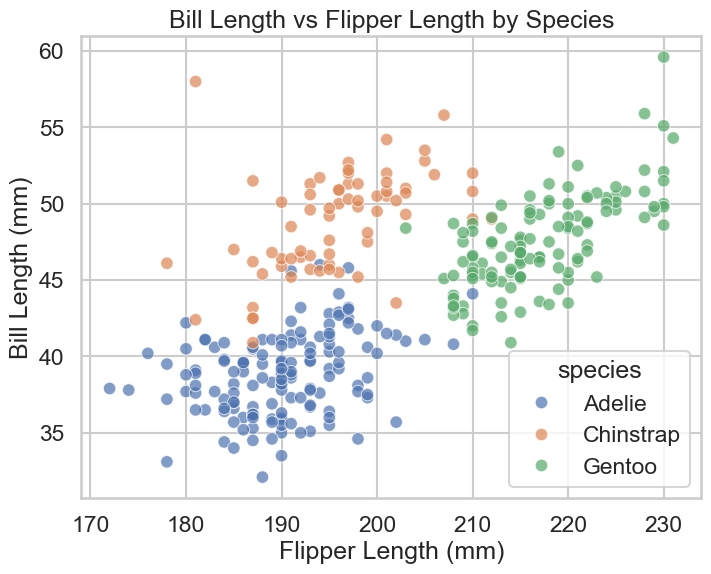

In [61]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="bill_length_mm",
    hue="species",
    alpha=0.7
) #FIX. SWITCH TO SCATTERPLOT!

plt.title("Bill Length vs Flipper Length by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")
plt.show()

### (Optional) switch to density plot

When many observations overlap, density plots can reveal clusters and patterns that are difficult to see in a scatter plot.

They highlight regions where observations are most concentrated.

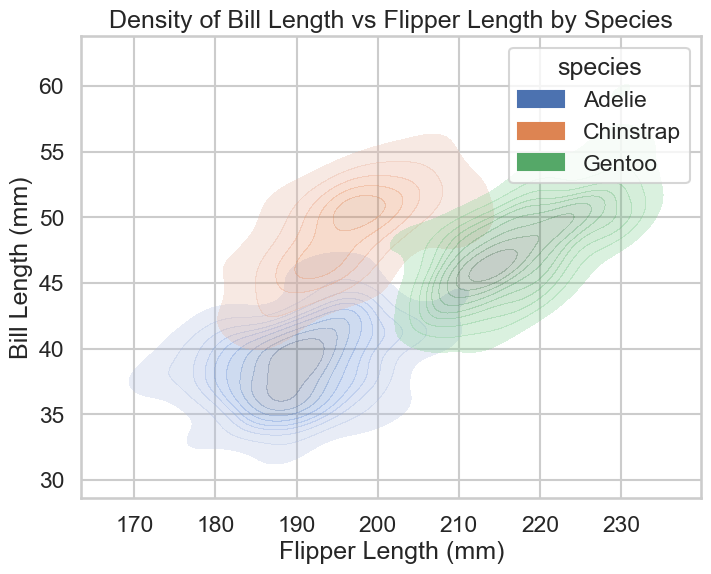

In [62]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="bill_length_mm",
    hue="species",
    fill=True,
    alpha=0.3
) #OPTIONAL FIX. SWITCH TO DENSITY PLOT

plt.title("Density of Bill Length vs Flipper Length by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Bill Length (mm)")
plt.show()

## Passengers by month and year

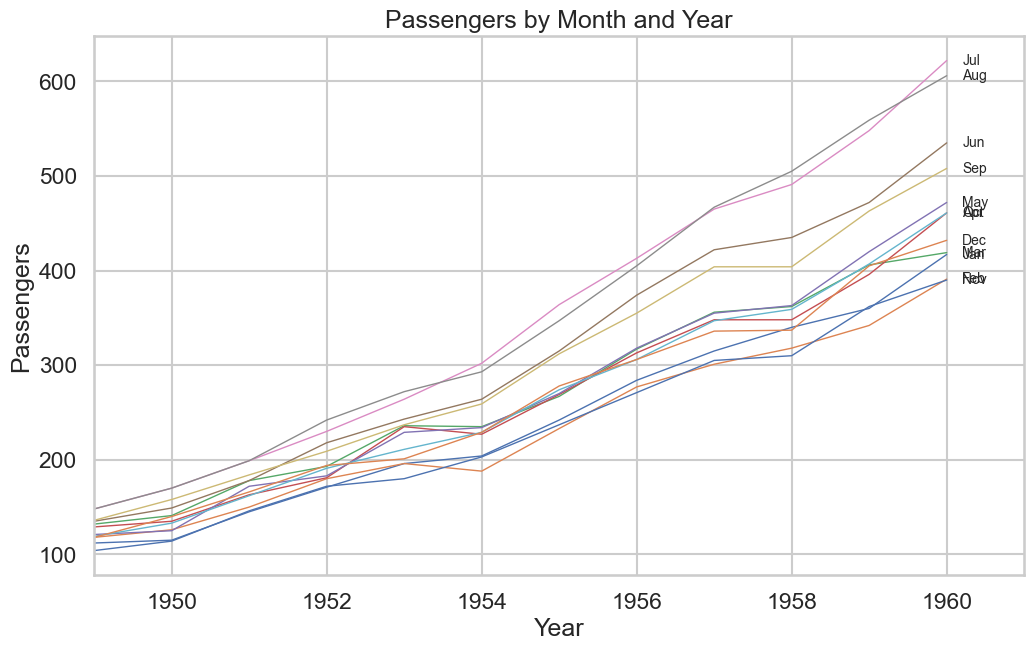

In [73]:
plt.figure(figsize=(12,7))

for col in flights_wide.columns:
    y = flights_wide[col]
    x = flights_wide.index
    
    plt.plot(x, y, linewidth=1)
    
    # label at the last data point
    plt.text(
        x[-1] + 0.2,
        y.iloc[-1],
        col,
        va="center",
        fontsize=10
    )

plt.title("Passengers by Month and Year")
plt.xlabel("Year")
plt.ylabel("Passengers")

# give labels space on the right
plt.xlim(x.min(), x.max() + 1)

plt.show()

### Add right type of legend

Legends require readers to match colors or line styles between the plot and the legend.

Direct labels placed near the lines reduce this extra cognitive step and make the chart easier to interpret.

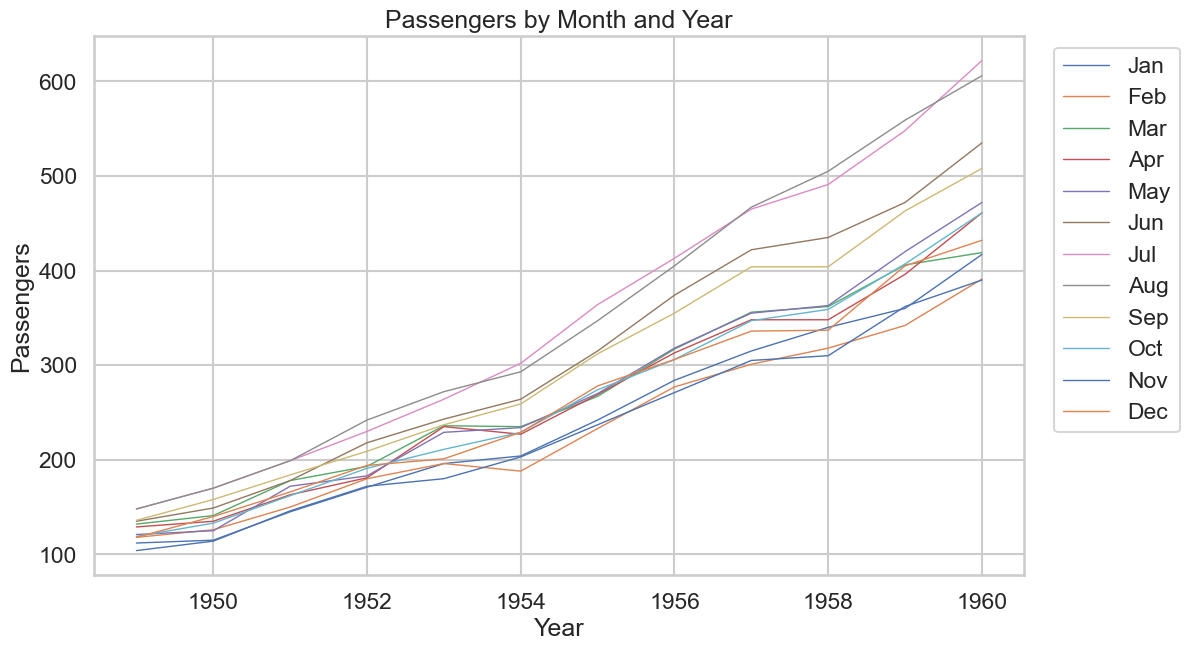

In [71]:
flights_wide = flights.pivot(index="year", columns="month", values="passengers")

plt.figure(figsize=(12,7))
for col in flights_wide.columns:
    plt.plot(flights_wide.index, flights_wide[col], linewidth=1, label=col)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left") #FIX. SWITCH FROM TEXT ON LINE TO LEGEND
plt.title("Passengers by Month and Year")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

### Switch to right type of plot

When many time series are plotted together, the chart can become cluttered and difficult to read.

A heatmap represents the same information using color intensity, which makes seasonal patterns and long-term trends easier to detect.

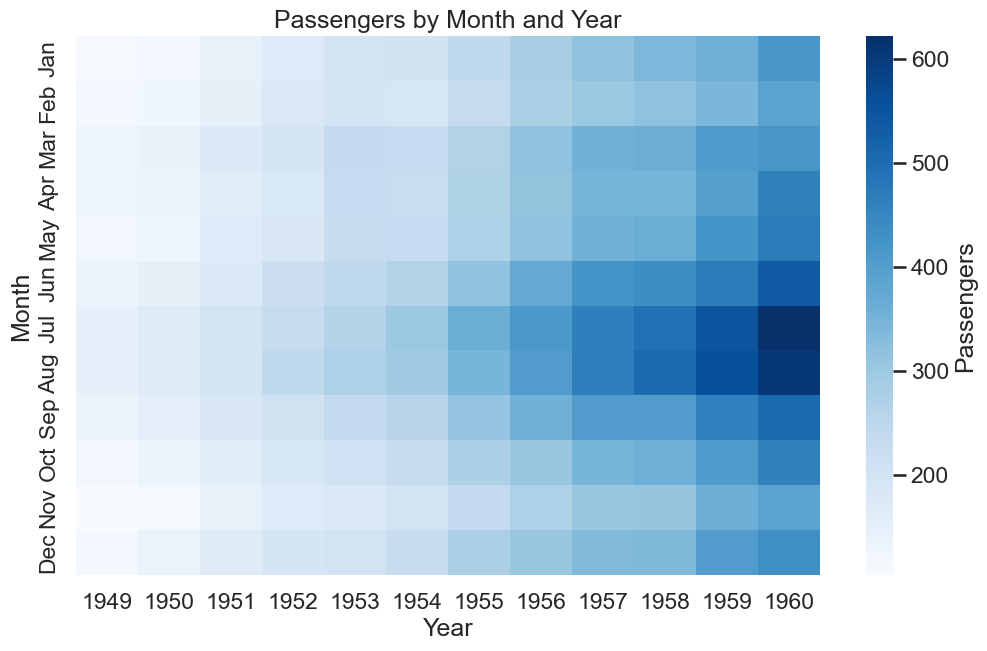

In [66]:
plt.figure(figsize=(12,7))
sns.heatmap(flights_wide.T, cmap="Blues", cbar_kws={"label": "Passengers"}) #FIX. CHANGE TO HEATMAP
plt.title("Passengers by Month and Year")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

# Visualization Do’s and Don’ts

## Do’s

### Choose the Right Chart Type
Use chart geometry that matches the structure of the data.

- **Line charts** → time trends  
- **Bar charts** → categorical comparisons  
- **Scatter plots** → relationships between variables  
- **Histograms / density plots** → distributions  

Good visualization starts with the right structure.

### Keep Visuals Simple
Remove elements that do not add information.

- Use simple color palettes
- Minimize unnecessary gridlines
- Avoid decorative effects

Every visual element should have a purpose.


### Make Comparisons Easy
The human brain compares **aligned lengths and positions** best.

- Sort categories when comparing values
- Use consistent ordering across plots
- Use horizontal bars when category labels are long

Reducing cognitive effort improves readability.


### Label Clearly
Help the reader understand the chart quickly.

- Add clear axis labels
- Use descriptive titles
- Add direct value labels when useful

A reader should understand the message in seconds.

### Use Color Purposefully
Color should encode information, not decoration.

- Use color to differentiate meaningful categories
- Use consistent palettes across plots
- Prefer simple sequential palettes for ordered data

Color should guide attention, not distract.

## Don’ts

### Don’t Use the Wrong Chart Type
Some chart types are simply inappropriate for certain data.

- Avoid pie charts for time series
- Avoid line charts when observations are independent
- Avoid scatterplots for categorical comparisons

The wrong chart type cannot be fixed with styling.

### Don’t Exaggerate Differences
Visual scales can distort perception.

- Avoid truncated axes in bar charts
- Avoid misleading scales
- Make sure visual differences match numerical differences

Charts should inform, not manipulate.

### Don’t Overload the Plot
Too much information reduces clarity.

- Avoid too many colors
- Avoid too many lines in a single chart
- Avoid overly large markers

Clutter hides the pattern you want to show.


### Don’t Force Readers to Decode Legends
Legends require extra effort to interpret.

- Prefer **direct labels** when possible
- Place labels near the data they describe
- Reduce unnecessary legend use

The reader should not have to hunt for meaning.


### Don’t Add Visual Noise
Unnecessary elements distract from the data.

- Avoid rainbow color maps
- Avoid unnecessary shadows or 3D effects
- Avoid heavy borders and excessive gridlines

Good plots emphasize data, not decoration.


# Final Checklist Before Publishing a Plot

Ask yourself:

1. What question does this chart answer?
2. Is this the right chart type for the data?
3. Are the scales honest and clear?
4. Can someone understand the plot in **five seconds**?
5. Is anything unnecessary that could be removed?

If the answer to any of these is **no**, revise the plot.